## Phase 2, Group 2 feature check — product count

`product_count_prev`, built by `src/features/build_features_product_count.py`,
sums how many of the 23 non-target product flags a customer holds as of
month *t-1* (`ind_tjcr_fin_ult1`, the Service A target, is deliberately
excluded — see the script docstring for why).

Unlike Group 1 (tenure/activity), this isn't a sanity check against a Phase
1 raw-column finding — product count is a newly derived feature with no
direct raw-column precedent, so this notebook is its first exploratory
look: does holding more products predict adopting a new one?

All rates below are computed on the **train split only**, to keep val
genuinely unseen even during this kind of diagnostic look.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent))

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_PATH = PROCESSED_DIR / "features_product_count.csv"
LABELS_PATH = PROCESSED_DIR / "adoption_labels_tjcr.csv"

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 50)

### Load features + adoption label, joined

`features_product_count.csv` has one row per (customer, label month) with
`product_count_prev`; `adoption_labels_tjcr.csv` has the `adoption` outcome
for that same (customer, month) key. Join on `(ncodpers, fecha_dato)` to
attach the label to each feature row.

In [2]:
features = pd.read_csv(
    FEATURES_PATH,
    dtype={
        "ncodpers": "int32",
        "split": "category",
        "product_count_prev": "int8",
        "product_count_missing": "bool",
    },
    parse_dates=["fecha_dato"],
)

labels = pd.read_csv(
    LABELS_PATH,
    usecols=["ncodpers", "fecha_dato", "adoption"],
    dtype={"ncodpers": "int32", "adoption": "float32"},
    parse_dates=["fecha_dato"],
)

merged = features.merge(labels, on=["ncodpers", "fecha_dato"], how="left")
matched = merged["adoption"].notna().mean()
print(f"feature rows matched to a defined adoption label: {matched:.2%}")

train = merged[(merged["split"] == "train") & merged["adoption"].notna()].copy()
train["adoption"] = train["adoption"].astype("int8")
print(f"train rows used below: {len(train):,}")

feature rows matched to a defined adoption label: 100.00%
train rows used below: 9,913,274


In [3]:
def adoption_rate_by(df, group_col, min_count=500):
    g = df.groupby(group_col, observed=True)["adoption"].agg(["mean", "count"])
    g = g.rename(columns={"mean": "rate"})
    return g[g["count"] >= min_count].sort_index()


def print_rate(df, label=None):
    if label:
        print(f"{label}:")
    print(df.assign(rate=df["rate"].map("{:.3%}".format)))


def plot_rate_bar(rate_df, title, ax=None):
    ax = ax or plt.subplots()[1]
    rate_df["rate"].plot(kind="bar", ax=ax, color="#1f6f5c")
    ax.set_ylabel("adoption rate")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
    plt.tight_layout()
    return ax

### Distribution of product_count_prev

How many of the 23 non-target products does a customer typically hold
before adopting (or not) the credit card?

product_count_prev
0     1616803
1     5368749
2     1485436
3      588959
4      338690
5      223403
6      150767
7       83048
8       36942
9       14060
10       4880
11       1266
12        232
13         31
14          8
Name: count, dtype: int64


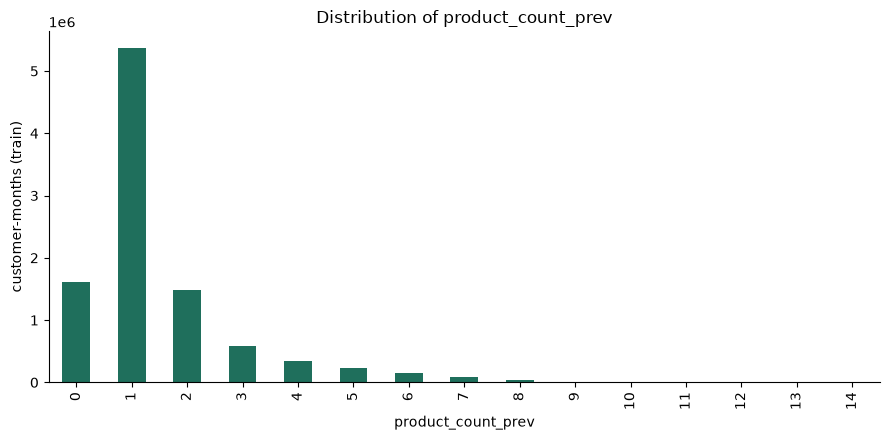

In [4]:
counts = train["product_count_prev"].value_counts().sort_index()
print(counts)
ax = counts.plot(kind="bar", color="#1f6f5c")
ax.set_xlabel("product_count_prev")
ax.set_ylabel("customer-months (train)")
ax.set_title("Distribution of product_count_prev")
plt.tight_layout()
plt.show()

### Adoption rate by product_count_prev

Most customers hold 0-2 other products; the tail (5+) is thin, so bucket
into wider bins there to keep counts stable for a reliable rate estimate.

product_count_prev (engineered):
                        rate    count
product_count_bucket                 
(-1, 0]               0.072%  1616803
(0, 1]                0.089%  5368749
(1, 2]                0.683%  1485436
(2, 3]                1.758%   588959
(3, 5]                3.114%   562093
(5, 20]               4.260%   291234


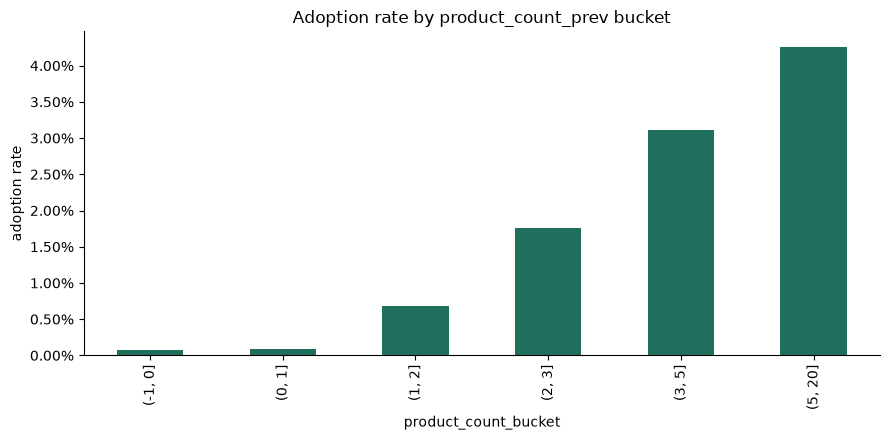

In [5]:
count_bins = [-1, 0, 1, 2, 3, 5, 20]
train["product_count_bucket"] = pd.cut(train["product_count_prev"], bins=count_bins)

rate_by_count = adoption_rate_by(train, "product_count_bucket")
print_rate(rate_by_count, "product_count_prev (engineered)")
plot_rate_bar(rate_by_count, "Adoption rate by product_count_prev bucket")
plt.show()

### Missingness and correlation

`product_count_missing` should be ~0% here (every labeled row has a t-1
profile row by construction of the label build — same as Group 1's 100%
match rate). The point-biserial correlation (pandas' `.corr()` on a 0/1
outcome) gives a quick numeric cross-check alongside the bucketed rates
above.

In [6]:
print(f"product_count_missing rate: {train['product_count_missing'].mean():.3%}")
corr = train[["product_count_prev", "adoption"]].corr()["adoption"].drop("adoption")
print(corr)

product_count_missing rate: 0.000%
product_count_prev    0.128358
Name: adoption, dtype: float64


### Conclusion

`product_count_prev` is the strongest signal found so far in this project
— adoption rate climbs roughly monotonically from ~0.07% (0 other
products) to ~4.3% (6+ products), a ~60x lift, with a point-biserial
correlation (~0.13) noticeably higher than tenure (~0.05) or activity index
(~0.08) from Group 1. This matches intuition: a customer already engaged
with several products is more reachable/more likely to adopt another than
one with almost no relationship to the bank.

One caveat to carry into modeling: this correlates with tenure (longer-
tenured customers accumulate more products), so its lift isn't fully
independent of Group 1's signal — something to check for when features are
combined (e.g. via feature importance / SHAP in Phase 3) rather than
treated as two separate, additive effects.

Group 2 is good to build on; next up is Group 3 (demographics: income, age,
sex, segmento).